In [1]:
# read the data


import os

import seaborn as sns

from scipy.stats import shapiro, kstest , pearsonr

from scipy.stats import gaussian_kde

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import umap
import plotly.graph_objects as go
from plotly.subplots import make_subplots

c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data reading 

In [2]:
data_folder = r"D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data\phenotype"
mppus= pd.read_csv(os.path.join(data_folder,"mppus_responses.tsv"),sep = '\t')
mppus['MPPUS_score'] = mppus.iloc[:, 1:].sum(axis=1)
sas = pd.read_csv(os.path.join(data_folder,"sas_responses.tsv"),sep = '\t')

sas['SAS_score'] = sas.iloc[:, 1:].sum(axis=1)
other = pd.read_csv(os.path.join(data_folder,"other_responses.tsv"),sep = '\t')

sas = sas[sas['participant_id'].str.contains("sd0")]
mppus = mppus[mppus['participant_id'].str.contains("sd0")]
other = other[other['participant_id'].str.contains("sd0")]


In [3]:
participants = pd.read_excel(r"E:\ecf-exp2-notif-mmn\data\Processed\Participant_details.xlsx")
participants.head()

,participant_id,age,is_controlled_block,gender,profession,b1_deviant,b2_deviant,b3_deviant
0,sd011,30,N,M,PG_acd,PN,BT,NaN
1,sd012,25,N,M,PG_acd,PN,BT,NaN
2,sd013,25,N,M,PG_acd,PN,BT,NaN
3,sd014,28,N,M,PG_acd,PN,BT,NaN
4,sd015,31,N,M,PG_acd,PN,BT,NaN


In [4]:
participants['profession'][~participants['profession'].str.contains('non')] ="ACD" 
participants['profession'][participants['profession'].str.contains('non')] ="Non-ACD" 
participants.head()

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_12668\1510411379.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  participants['profession'][~participants['profession'].str.contains('non')] ="ACD"
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_12668\1510411379.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  participants['profession'][participants['profession'].str.contains('non')] ="Non-ACD"


,participant_id,age,is_controlled_block,gender,profession,b1_deviant,b2_deviant,b3_deviant
0,sd011,30,N,M,ACD,PN,BT,NaN
1,sd012,25,N,M,ACD,PN,BT,NaN
2,sd013,25,N,M,ACD,PN,BT,NaN
3,sd014,28,N,M,ACD,PN,BT,NaN
4,sd015,31,N,M,ACD,PN,BT,NaN


In [5]:
sas.head()

,participant_id,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,...,Q25,Q26,Q27,Q28,Q29,Q30,Q31,Q32,Q33,SAS_score
9,sd011,3,6,2,4,3,3,4,2,2,...,2,1,1.0,6.0,5,5,6,6,4,91.0
11,sd012,1,4,1,3,3,1,4,1,4,...,4,1,5.0,4.0,4,4,4,2,2,76.0
13,sd013,3,2,3,4,4,4,6,4,5,...,2,1,5.0,6.0,5,4,3,3,2,102.0
14,sd014,2,3,5,2,5,4,3,3,3,...,1,1,2.0,2.0,5,2,2,4,2,88.0
15,sd015,5,5,3,5,5,2,5,5,4,...,5,1,5.0,2.0,5,5,5,3,2,119.0


# Cronbach’s alpha reliability test

In [6]:
import pandas as pd
import numpy as np

def cronbach_alpha(df):
    """
    Compute Cronbach's alpha from item response DataFrame (numeric only).
    """
    k = df.shape[1]
    item_variances = df.var(axis=0, ddof=1)
    total_score = df.sum(axis=1)
    total_variance = total_score.var(ddof=1)
    alpha = (k / (k - 1)) * (1 - item_variances.sum() / total_variance)
    return alpha


sas_alpha = cronbach_alpha(sas.iloc[:, 1:-1])
print(f" SAS Cronbach’s alpha: {sas_alpha:.3f}")

mppus_alpha = cronbach_alpha(mppus.iloc[:, 1:-1])
print(f" MPPUS Cronbach’s alpha: {mppus_alpha:.3f}")

 SAS Cronbach’s alpha: 0.903
 MPPUS Cronbach’s alpha: 0.854


# Correlation between MPPUS and SAS

In [7]:

# Shapiro-Wilk test
shapiro_mppus = shapiro(mppus['MPPUS_score'])
shapiro_sas = shapiro(sas['SAS_score'])
print("Shapiro-Wilk Test for MPPUS:", shapiro_mppus[0])
print("Shapiro-Wilk Test for SAS:", shapiro_sas[0])




Shapiro-Wilk Test for MPPUS: 0.9834249772289585
Shapiro-Wilk Test for SAS: 0.9779576792014636


In [8]:


# Calculate correlation coefficient
corr_coeff, p_value= pearsonr(sas['SAS_score'], mppus['MPPUS_score'])
print(corr_coeff, p_value)

0.7564342510668429 1.011135542563579e-11


In [9]:
 # Calculate 30th and 70th percentiles for SAS
sas_30 = sas['SAS_score'].quantile(0.30) 
sas_70 = sas['SAS_score'].quantile(0.70) 

# Create figure and axes

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, gridspec_kw={'width_ratios': [1, 1]},dpi =1000)  # Share y-axis for alignment
scatter_ax, hist_ax = axes

# === First subplot: Correlation Scatter Plot === #
# Color code based on SAS percentiles
colors = np.where(sas['SAS_score'] >= sas_70, 'darkorange', 
                  np.where(sas['SAS_score'] <= sas_30,'deepskyblue', 'black'))
colors = colors.tolist()
# Scatter plot
#scatter_ax.scatter(subject_info_D['MPPUS score'], subject_info_D['SAS score'], c=colors, alpha=0.8, edgecolor='k', s=70)
# Scatter plot with regression line (on the right subplot)
sns.regplot(x = mppus['MPPUS_score'], y=  sas['SAS_score'], ax=scatter_ax,
            scatter_kws={"color": colors, "s": 70, "edgecolor": "black"},line_kws=dict(color="grey",alpha=0.8,linewidth = 3)  )

scatter_ax.text(0.75, 0.65, f"r = {corr_coeff:.2f}", transform=scatter_ax.transAxes, fontsize=20, color='black')
scatter_ax.set_xlabel('MPPUS')
scatter_ax.set_ylabel('SAS')
scatter_ax.axhline(sas_30, color='deepskyblue', linestyle='solid',linewidth = 3, label='30th Percentile')
scatter_ax.axhline(sas_70, color='darkorange', linestyle='solid', linewidth = 3, label='70th Percentile')
# Add legend
scatter_ax.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange', markersize=10, label='HSU Group'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='deepskyblue', markersize=10, label='LSU Group'),
    #plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, label='Avg. Smartphone User Group'),
], loc='upper left',handletextpad=0.2)
# === Second subplot: SAS Histogram === #
hist_ax.hist(sas['SAS_score'], bins=10, alpha=0.4,  color='grey',orientation='horizontal',edgecolor='black')

hist_ax.axhline(sas_30, color='deepskyblue', linestyle='solid',linewidth = 3, label='30th Percentile')
hist_ax.axhline(sas_70, color='darkorange', linestyle='solid', linewidth = 3, label='70th Percentile')

hist_ax.set_xlabel('Count')
hist_ax.legend()
# Remove space between plots
for s,spine in enumerate(axes[0].spines.values()):
    if s !=0 and s != 2 :
        print(s,spine)
        spine.set_visible(False)
# Remove space between plots
for s,spine in enumerate(axes[1].spines.values()):
    if s !=2 :
        print(s,spine)
        spine.set_visible(False)
plt.subplots_adjust(wspace=0.0)
# Adjust layout and show plot
plt.tight_layout()
plt.rcParams.update({
    'xtick.labelsize': 15,  # X-axis tick labels font size
    'ytick.labelsize': 15,  # Y-axis tick labels font size
    'axes.labelsize': 15,   # Axis label font size
    'axes.titlesize': 15,   # Title font size
    'legend.fontsize': 15,   # Legend font size
})
plt.show()


1 Spine
3 Spine
0 Spine
1 Spine
3 Spine


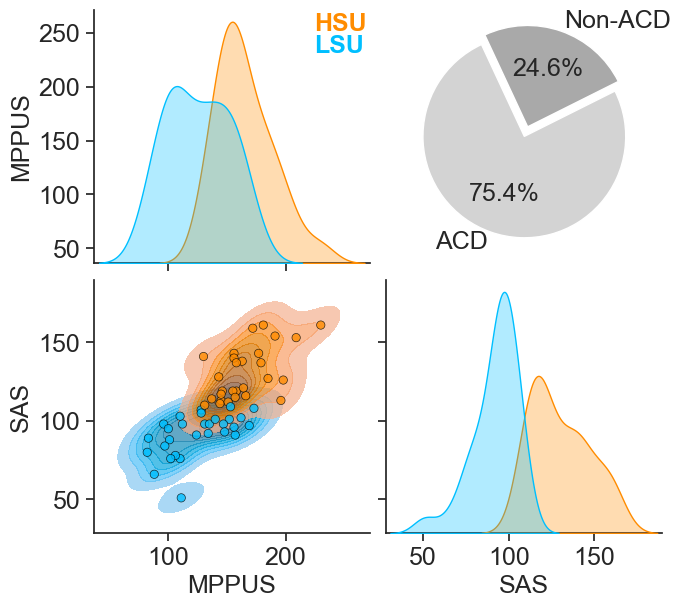

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example DataFrame structure
# Replace this with your actual data
data = {
    'SAS': sas['SAS_score'],
    'MPPUS': mppus['MPPUS_score'],
    'UserGroup': sas['GMM_Cluster']
}
df = pd.DataFrame(data)
# Create the pairplot

sns.set_theme(style="ticks")

g = sns.pairplot(df, 
                 vars=[ 'MPPUS','SAS'],
                 hue='UserGroup',         # Color by group
                 kind = 'kde',
                 plot_kws=dict(fill=True,alpha=0.7),
                 diag_kws=dict(fill=True,alpha=0.3),
                 diag_kind='kde',         # KDE plots on the diagonal
                 markers=["o", "s"],      # Different markers for groups
                 height=3,        # Each subplot is 5 inches tall
                 aspect=1.1,       # Each subplot is 1.2 times as wide as it is tall
                 palette={0: 'deepskyblue', 1: 'darkorange'},

                )
g._legend.remove()
g.map_lower(sns.scatterplot,alpha=0.8,edgecolor='black')
g.map_upper(sns.scatterplot,alpha=0.8,edgecolor='black')
ax = g.axes[0, 0]
# For the first group color
ax.text(
     0.80, 0.90,"LSU", 
    color=g.palette[0],  # or color=g.palette[0] if available
    fontsize=18, weight="bold", ha='left', va='top', 
    transform=ax.transAxes, zorder=10
)
# For the second group color
ax.text(
    0.80, 0.99, "HSU", 
    color=g.palette[1],  # or color=g.palette[1]
    fontsize=18, weight="bold", ha='left', va='top', 
    transform=ax.transAxes, zorder=10
)
for ax in g.axes.flat:
   ax.tick_params(axis='x', labelsize=18)  # Set x-tick label size
   ax.tick_params(axis='y', labelsize=18)  # Set y-tick label size (optional)
   ax.xaxis.label.set_size(18)  # X-axis label
   ax.yaxis.label.set_size(18)  # Y-axis label
# Example pie data from another column in your dataframe
pie_data = participants['profession'].value_counts()
labels = pie_data.index

# You may need to adjust these values to position the pie over the top right subplot
pos = g.axes[0, 1].get_position()
pie_ax = g.figure.add_axes([pos.x0, pos.y0, pos.width, pos.height]) # [left, bottom, width, height]
explode = [0, 0.1,]

pie_ax.pie(
    pie_data, 
    labels=labels, 
    autopct='%1.1f%%', 
    explode=explode,
    textprops={'fontsize': 18}, 
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
    colors=["lightgrey",'darkgrey'], 
    startangle=115
)
pie_ax.set_aspect('equal')
g.axes[0, 1].set_visible(False)
fig = plt.gcf()
fig.patch.set_alpha(0.0)
for ax in fig.axes:
    ax.patch.set_alpha(0.0)

plt.show()


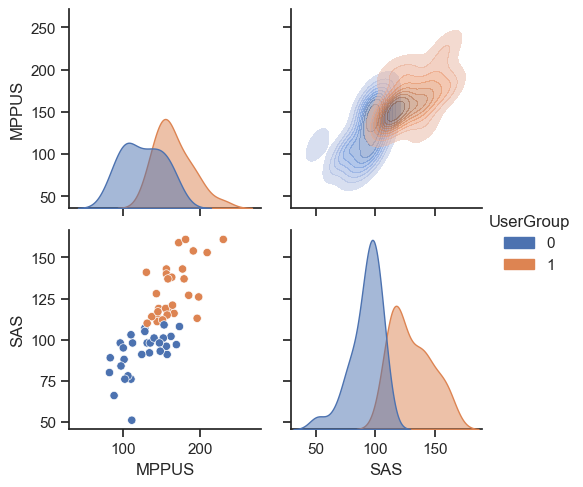

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example DataFrame
# df = your dataframe

g = sns.PairGrid(df, vars=['MPPUS', 'SAS'], hue='UserGroup')

# Lower triangle: scatter plot
g.map_lower(sns.scatterplot)

# Upper triangle: KDE plot
g.map_upper(sns.kdeplot, fill=True, alpha=0.5)

# Diagonal: KDE plot (1D)
g.map_diag(sns.kdeplot, fill=True, alpha=0.5)

g.add_legend()
plt.show()


In [ ]:
g.axes

array([[<Axes: ylabel='MPPUS'>, <Axes: xlabel='SAS', ylabel='MPPUS'>],
       [<Axes: xlabel='MPPUS', ylabel='SAS'>, <Axes: xlabel='SAS'>]],
      dtype=object)

# Dimensional reduction

In [11]:
#questionnaire data
sas_columns = [f'Q{i}' for i in range(1, 34)]
X_df = sas[sas_columns]

X_fixed = X_df.fillna(X_df.median()).values

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_fixed)

# 1. PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# 3. UMAP
reducer = umap.UMAP(random_state=42,n_epochs = 500,min_dist = 0.05,n_neighbors= 8)
X_umap = reducer.fit_transform(X_scaled)


c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


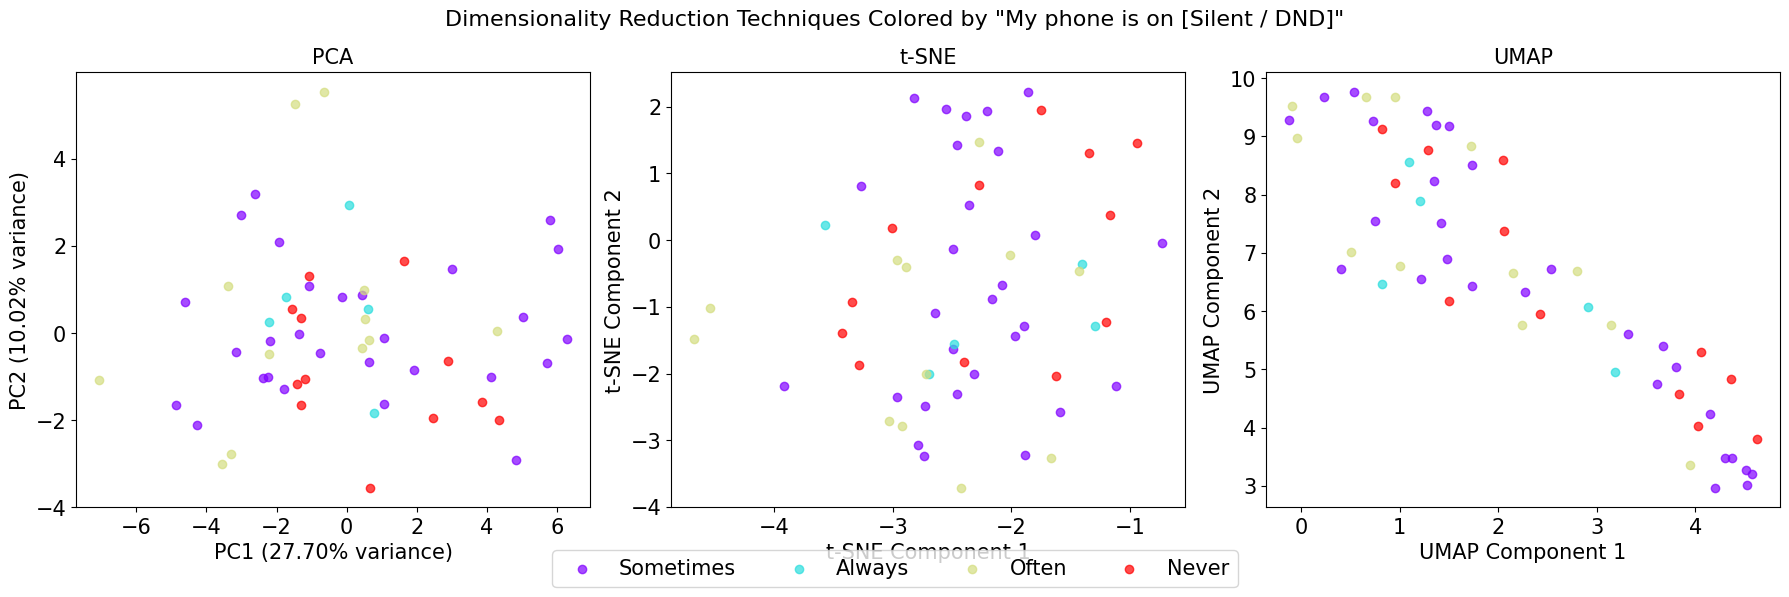

In [12]:




# Create a figure with 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Dimensionality Reduction Techniques Colored by "My phone is on [Silent / DND]"', fontsize=16)

# Get unique values for Q2 column
categories =other['Q2'].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(categories)))

# Plot PCA
for i, category in enumerate(categories):
    mask =other['Q2'] == category
    axs[0].scatter(X_pca[mask, 0], X_pca[mask, 1], color=colors[i], label=category, alpha=0.7)
axs[0].set_title('PCA')
axs[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
axs[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')

# Plot t-SNE
for i, category in enumerate(categories):
    mask =other['Q2'] == category
    axs[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], color=colors[i], label=category, alpha=0.7)
axs[1].set_title('t-SNE')
axs[1].set_xlabel('t-SNE Component 1')
axs[1].set_ylabel('t-SNE Component 2')

# Plot UMAP
for i, category in enumerate(categories):
    mask =other['Q2'] == category
    axs[2].scatter(X_umap[mask, 0], X_umap[mask, 1], color=colors[i], label=category, alpha=0.7)
axs[2].set_title('UMAP')
axs[2].set_xlabel('UMAP Component 1')
axs[2].set_ylabel('UMAP Component 2')

# Add legend to the figure (outside the plots)
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(categories), bbox_to_anchor=(0.5, 0))

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # Make room for the legend
plt.savefig('dimensionality_reduction_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


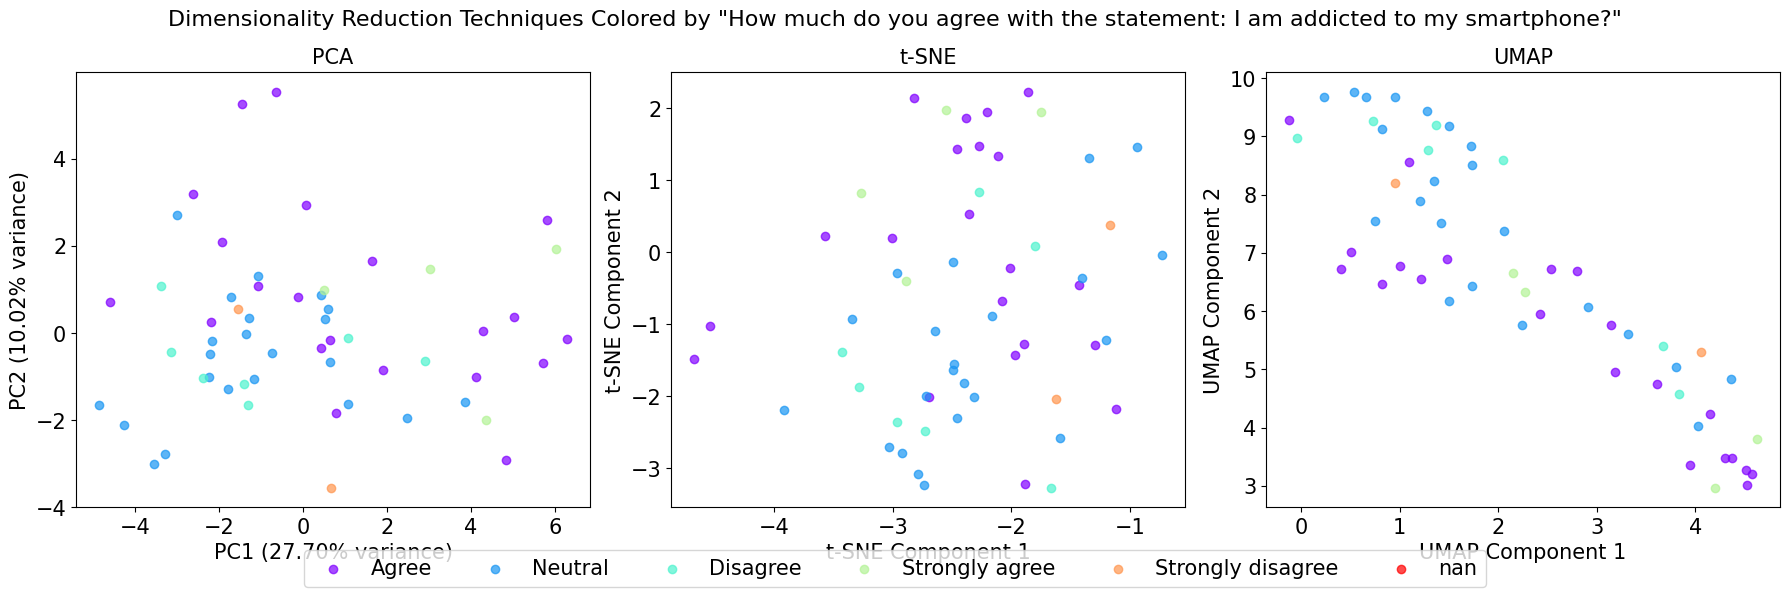

In [13]:
# Create a figure with 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Dimensionality Reduction Techniques Colored by "How much do you agree with the statement: I am addicted to my smartphone?"', fontsize=16)

# Get unique values for Q2 column
categories =other['Q1'].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(categories)))

# Plot PCA
for i, category in enumerate(categories):
    mask =other['Q1'] == category
    axs[0].scatter(X_pca[mask, 0], X_pca[mask, 1], color=colors[i], label=category, alpha=0.7)
axs[0].set_title('PCA')
axs[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
axs[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')

# Plot t-SNE
for i, category in enumerate(categories):
    mask =other['Q1'] == category
    axs[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], color=colors[i], label=category, alpha=0.7)
axs[1].set_title('t-SNE')
axs[1].set_xlabel('t-SNE Component 1')
axs[1].set_ylabel('t-SNE Component 2')

# Plot UMAP
for i, category in enumerate(categories):
    mask =other['Q1'] == category
    axs[2].scatter(X_umap[mask, 0], X_umap[mask, 1], color=colors[i], label=category, alpha=0.7)
axs[2].set_title('UMAP')
axs[2].set_xlabel('UMAP Component 1')
axs[2].set_ylabel('UMAP Component 2')

# Add legend to the figure (outside the plots)
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(categories), bbox_to_anchor=(0.5, 0))

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # Make room for the legend
plt.savefig('dimensionality_reduction_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

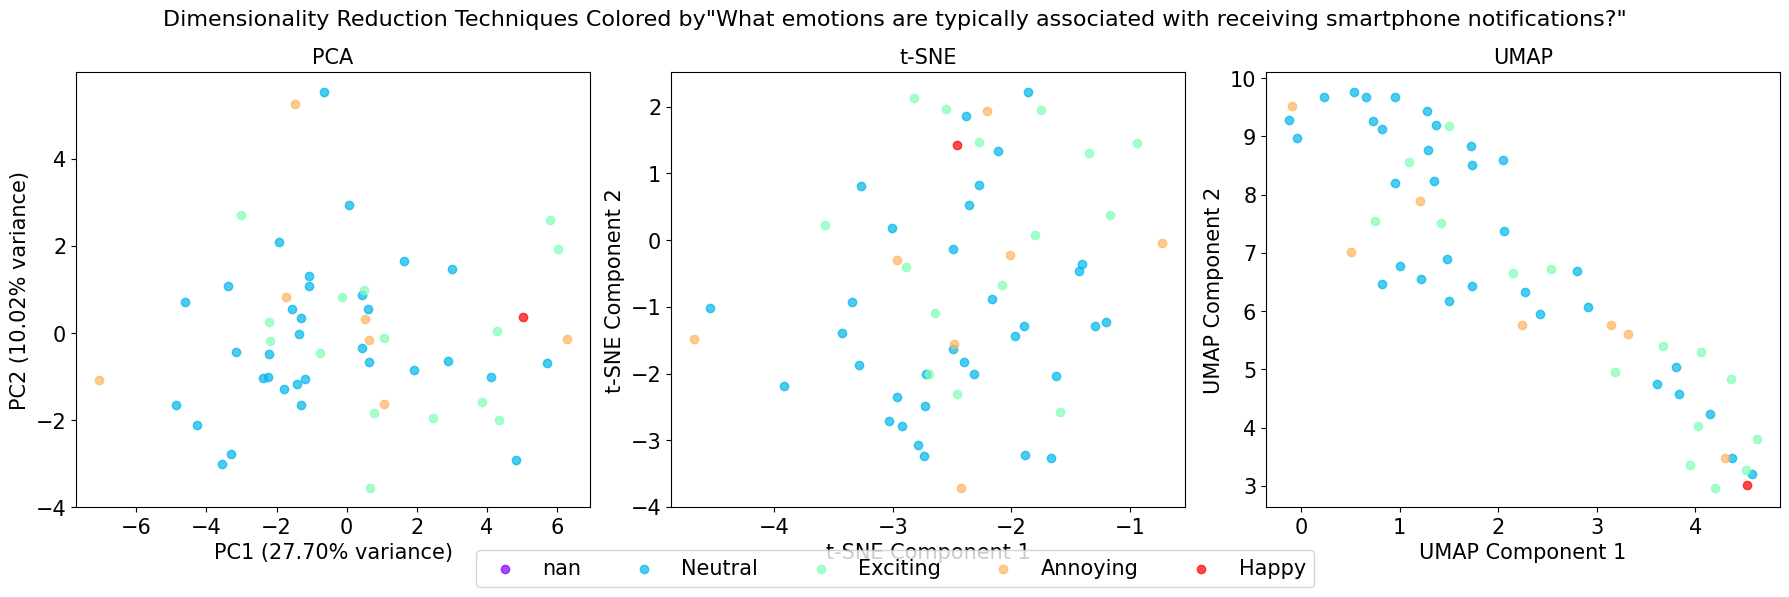

In [14]:
# Create a figure with 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Dimensionality Reduction Techniques Colored by"What emotions are typically associated with receiving smartphone notifications?"', fontsize=16)

# Get unique values for Q2 column
categories =other['Q6'].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(categories)))

# Plot PCA
for i, category in enumerate(categories):
    mask =other['Q6'] == category
    axs[0].scatter(X_pca[mask, 0], X_pca[mask, 1], color=colors[i], label=category, alpha=0.7)
axs[0].set_title('PCA')
axs[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
axs[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')

# Plot t-SNE
for i, category in enumerate(categories):
    mask =other['Q6'] == category
    axs[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], color=colors[i], label=category, alpha=0.7)
axs[1].set_title('t-SNE')
axs[1].set_xlabel('t-SNE Component 1')
axs[1].set_ylabel('t-SNE Component 2')

# Plot UMAP
for i, category in enumerate(categories):
    mask =other['Q6'] == category
    axs[2].scatter(X_umap[mask, 0], X_umap[mask, 1], color=colors[i], label=category, alpha=0.7)
axs[2].set_title('UMAP')
axs[2].set_xlabel('UMAP Component 1')
axs[2].set_ylabel('UMAP Component 2')

# Add legend to the figure (outside the plots)
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(categories), bbox_to_anchor=(0.5, 0))

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # Make room for the legend
plt.savefig('dimensionality_reduction_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# SAS score based clustering 

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering,DBSCAN,SpectralClustering
from sklearn.mixture import GaussianMixture,BayesianGaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

clusterings = {
    "KMeans": KMeans(n_clusters=2, random_state=42),
    "GMM": GaussianMixture(n_components=2, random_state=42),
    "Agglomerative": AgglomerativeClustering(n_clusters=2),
    #"DBSCAN": DBSCAN(eps=2.0, min_samples=5),  # You may need to tune these
    #"BayesGMM" :  BayesianGaussianMixture(n_components=10, random_state=42)
    "Spectral" : SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=42)
}


# Store clustering labels
for name, model in clusterings.items():
    if name == "GMM":
        sas[f"{name}_Cluster"] = model.fit_predict(X_scaled)
    else:
        sas[f"{name}_Cluster"] = model.fit(X_scaled).fit_predict(X_scaled)



# -----------------------------
# 4. Evaluate and Compare
# -----------------------------
print("\n🔍 Clustering Evaluation:")

for name, labels in clusterings.items():
    sil = silhouette_score(X_scaled, sas[f"{name}_Cluster"])
    ch = calinski_harabasz_score(X_scaled, sas[f"{name}_Cluster"])
    db = davies_bouldin_score(X_scaled, sas[f"{name}_Cluster"])

    # Cluster sizes
    unique, counts = np.unique(sas[f"{name}_Cluster"], return_counts=True)
    cluster_sizes = dict(zip(unique, counts))

    print(f"\n{name}:")
    print(f"  Silhouette Score:         {sil:.3f}")
    print(f"  Calinski-Harabasz Score:  {ch:.1f}")
    print(f"  Davies-Bouldin Score:     {db:.3f}")
    print(f"  Cluster Sizes:            {cluster_sizes}")



🔍 Clustering Evaluation:

KMeans:
  Silhouette Score:         0.148
  Calinski-Harabasz Score:  12.7
  Davies-Bouldin Score:     2.045
  Cluster Sizes:            {0: 29, 1: 28}

GMM:
  Silhouette Score:         0.148
  Calinski-Harabasz Score:  12.7
  Davies-Bouldin Score:     2.045
  Cluster Sizes:            {0: 29, 1: 28}

Agglomerative:
  Silhouette Score:         0.166
  Calinski-Harabasz Score:  11.7
  Davies-Bouldin Score:     1.948
  Cluster Sizes:            {0: 40, 1: 17}

Spectral:
  Silhouette Score:         0.161
  Calinski-Harabasz Score:  12.6
  Davies-Bouldin Score:     1.987
  Cluster Sizes:            {0: 21, 1: 36}


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr

def plot_cluster_group(mppus_df, sas_df, cluster_col, ax):
    x = mppus_df["MPPUS_score"]
    y = sas_df["SAS_score"]
    clusters = sas_df[f"{cluster_col}_Cluster"].to_list()
    

    # Cluster color palette
    palette = {0: "#1f77b4", 1: "#ff7f0e",-1: "gray",}  # blue and orange
    sns.scatterplot(x=x, y=y, hue=clusters, palette=palette, ax=ax, s=50, edgecolor="black", alpha=0.8)

    # Regression line
    sns.regplot(x=x, y=y, scatter=False, ax=ax, color="gray", line_kws={"linewidth": 2, "alpha": 0.6})

    # Pearson correlation
    r, _ = pearsonr(x, y)
    ax.text(x.max() - 20, y.min() + 5, f"r = {r:.2f}", fontsize=14, weight="bold", color="black")

    # Horizontal lines (on Y = SAS axis)
    y_hsu = np.percentile(y, 75)
    y_lsu = np.percentile(y, 25)
    ax.axhline(y=y_hsu, color=palette[1], linewidth=2)
    ax.axhline(y=y_lsu, color=palette[0], linewidth=2)

    # Group labels
    ax.text(x.min() + 5, y_hsu + 3, "HSU Group", color=palette[1], fontsize=13, weight="bold")
    ax.text(x.min() + 5, y_lsu - 6, "LSU Group", color=palette[0], fontsize=13, weight="bold")

    # Axis labels
    ax.set_title(cluster_col.replace("_Cluster", ""), fontsize=14)
    ax.set_xlabel("MPPUS Total Score")
    ax.set_ylabel("SAS Total Score")
    ax.legend_.remove()


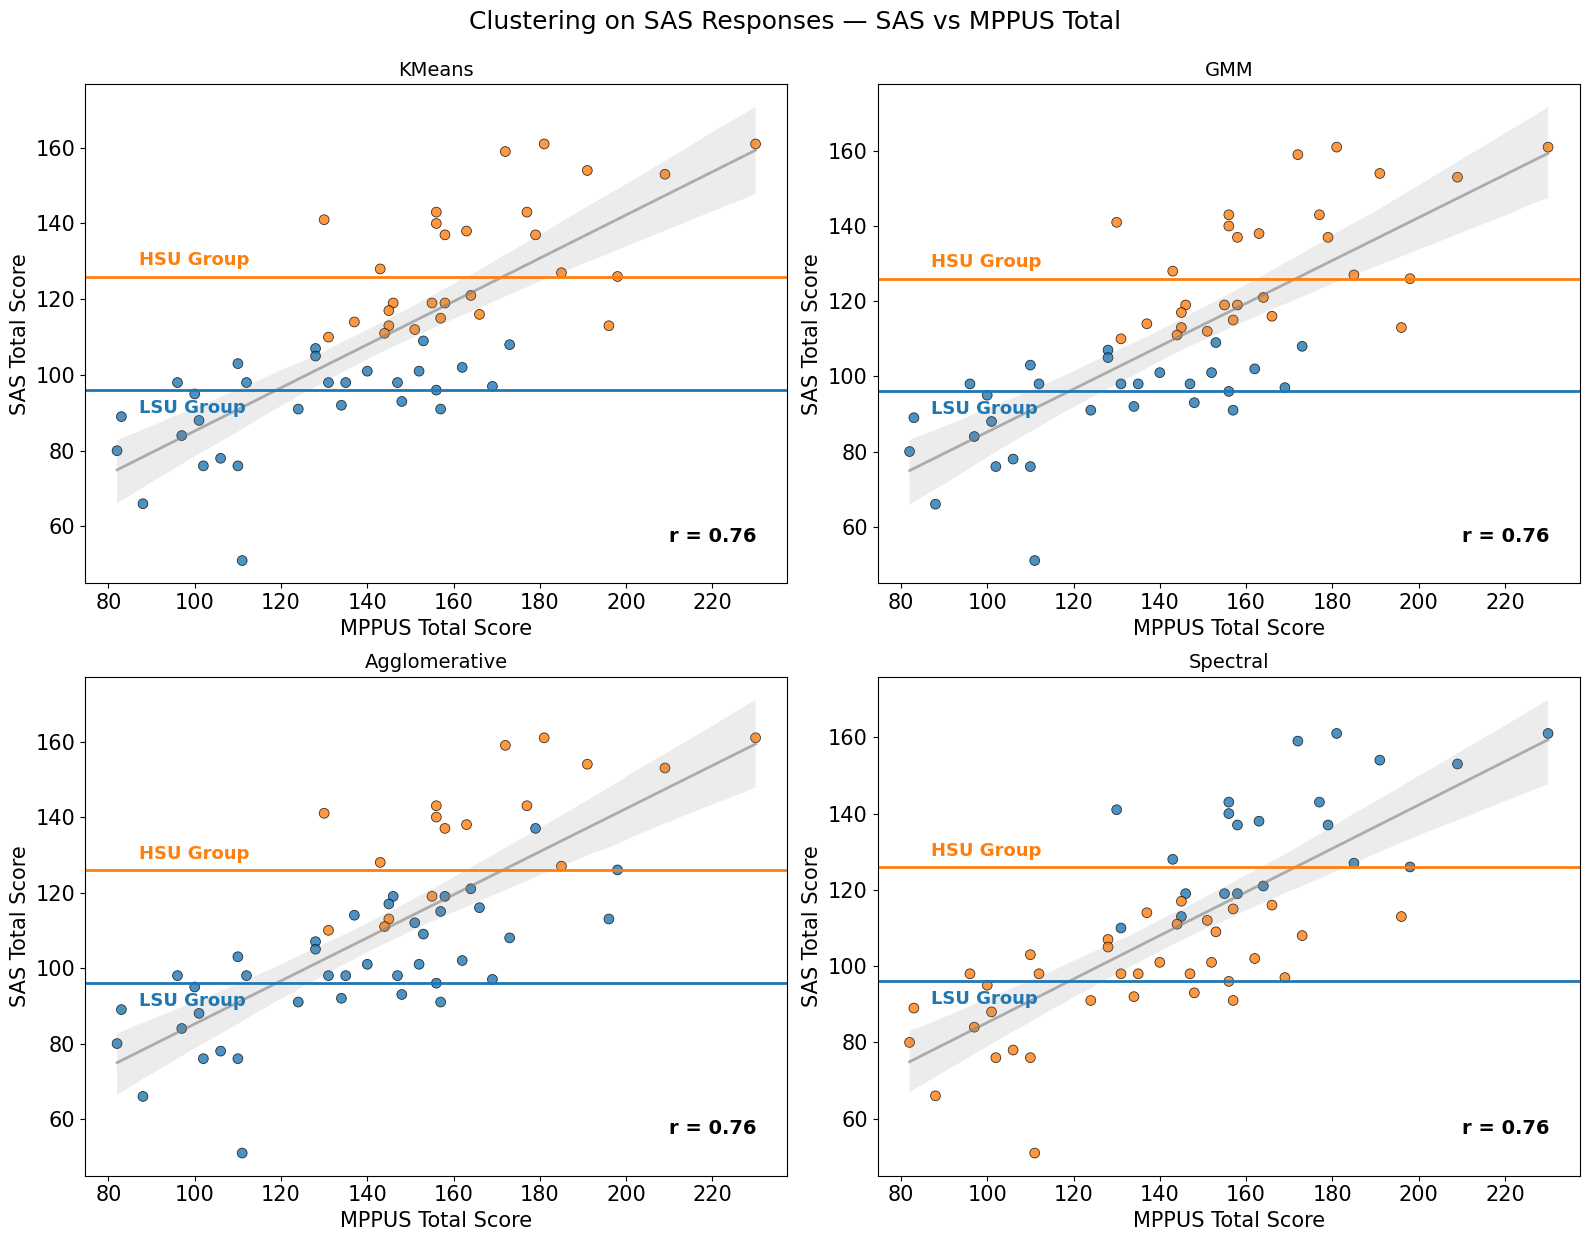

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
cluster_cols = clusterings.keys()

for ax, col in zip(axes.flatten(), cluster_cols):
    plot_cluster_group(mppus,sas, col, ax)

plt.tight_layout()
plt.suptitle("Clustering on SAS Responses — SAS vs MPPUS Total", fontsize=18, y=1.03)
plt.show()


In [18]:
sas.head()

,participant_id,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,...,Q29,Q30,Q31,Q32,Q33,SAS_score,KMeans_Cluster,GMM_Cluster,Agglomerative_Cluster,Spectral_Cluster
9,sd011,3,6,2,4,3,3,4,2,2,...,5,5,6,6,4,91.0,0,0,0,1
11,sd012,1,4,1,3,3,1,4,1,4,...,4,4,4,2,2,76.0,0,0,0,1
13,sd013,3,2,3,4,4,4,6,4,5,...,5,4,3,3,2,102.0,0,0,0,1
14,sd014,2,3,5,2,5,4,3,3,3,...,5,2,2,4,2,88.0,0,0,0,1
15,sd015,5,5,3,5,5,2,5,5,4,...,5,5,5,3,2,119.0,1,1,0,0


**Axes (Q1–Q33):** Each spoke represents one SAS questionnaire item (Q1 to Q33).

**Distance from Center**: The further out from the center, the higher the average score for that question in the cluster.

**Lines and Shading:**

Blue Line (Cluster 0): Shows the average response for each question among users in Cluster 0.

Orange Line (Cluster 1): Shows the average response for each question among users in Cluster 1.

The filled area under each line helps visualize the overall pattern and magnitude for each cluster.

What the Plot Shows
Cluster 1 Consistently Higher: For nearly every question, the orange line (Cluster 1) is outside the blue line (Cluster 0), meaning Cluster 1 has higher average scores on almost all SAS items.

Interpretation:

Cluster 1 likely represents "heavy" or more addicted smartphone users, as they score higher on all or most addiction-related questions.

Cluster 0 represents "light" or less addicted users, with lower average scores.

Pattern Consistency: The shapes of the two lines are similar, indicating that the relative pattern of responses across questions is alike in both groups, but Cluster 1 consistently scores higher.

Insights
Separation: The clear separation between the two lines across most questions suggests the clusters are meaningfully different in their smartphone use/addiction profiles.

No Single Question Drives the Difference: The difference is broad across the scale, not limited to just a few items.

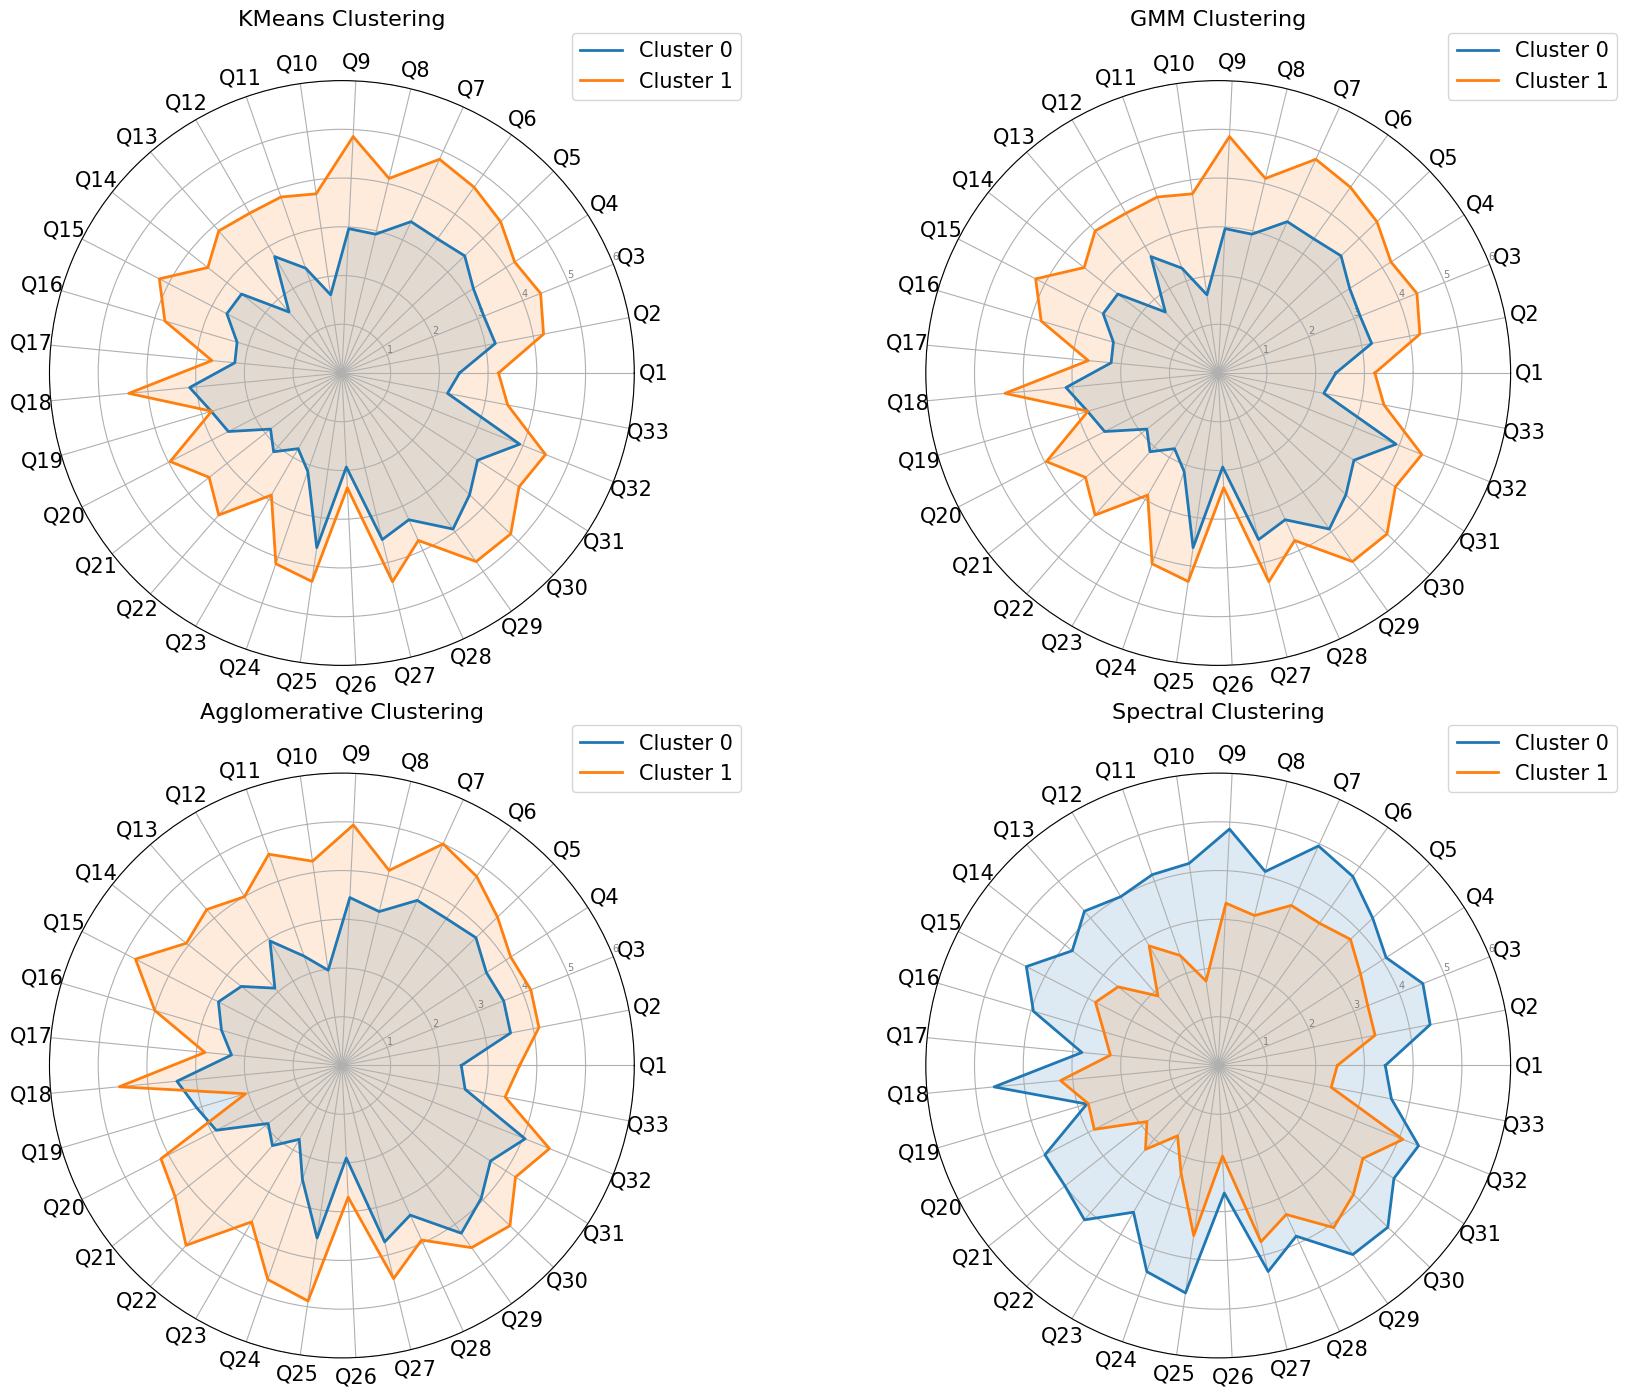

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# List of SAS item columns
sas_columns = [f'Q{i}' for i in range(1, 34)]
algos = ["KMeans", "GMM", "Agglomerative", "Spectral"]

# Set up radar plot angles
N = len(sas_columns)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # complete the loop

fig, axes = plt.subplots(2, 2, subplot_kw=dict(polar=True), figsize=(18, 14))
axes = axes.flatten()

for idx, algo in enumerate(algos):
    ax = axes[idx]
    cluster_col = f"{algo}_Cluster"
    # Exclude noise points for DBSCAN if present (-1 label)
    clusters = sorted([c for c in sas[cluster_col].unique() if c != -1])
    for cluster in clusters:
        means = sas[sas[cluster_col] == cluster][sas_columns].mean().tolist()
        means += means[:1]  # complete the loop
        ax.plot(angles, means, linewidth=2, label=f"Cluster {cluster}")
        ax.fill(angles, means, alpha=0.15)
    ax.set_title(f"{algo} Clustering", size=16, y=1.08)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(sas_columns, size=15)
    ax.set_yticks([1, 2, 3, 4, 5, 6])
    ax.set_yticklabels(['1', '2', '3', '4', '5', '6'], color="grey", size=7)
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()
plt.show()


## Subject with EEG data

In [20]:
mppus_eeg=mppus[mppus['participant_id'].str.contains("sd0")]
sas_eeg=sas[sas['participant_id'].str.contains("sd0")]
sas_eeg.head()

,participant_id,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,...,Q29,Q30,Q31,Q32,Q33,SAS_score,KMeans_Cluster,GMM_Cluster,Agglomerative_Cluster,Spectral_Cluster
9,sd011,3,6,2,4,3,3,4,2,2,...,5,5,6,6,4,91.0,0,0,0,1
11,sd012,1,4,1,3,3,1,4,1,4,...,4,4,4,2,2,76.0,0,0,0,1
13,sd013,3,2,3,4,4,4,6,4,5,...,5,4,3,3,2,102.0,0,0,0,1
14,sd014,2,3,5,2,5,4,3,3,3,...,5,2,2,4,2,88.0,0,0,0,1
15,sd015,5,5,3,5,5,2,5,5,4,...,5,5,5,3,2,119.0,1,1,0,0


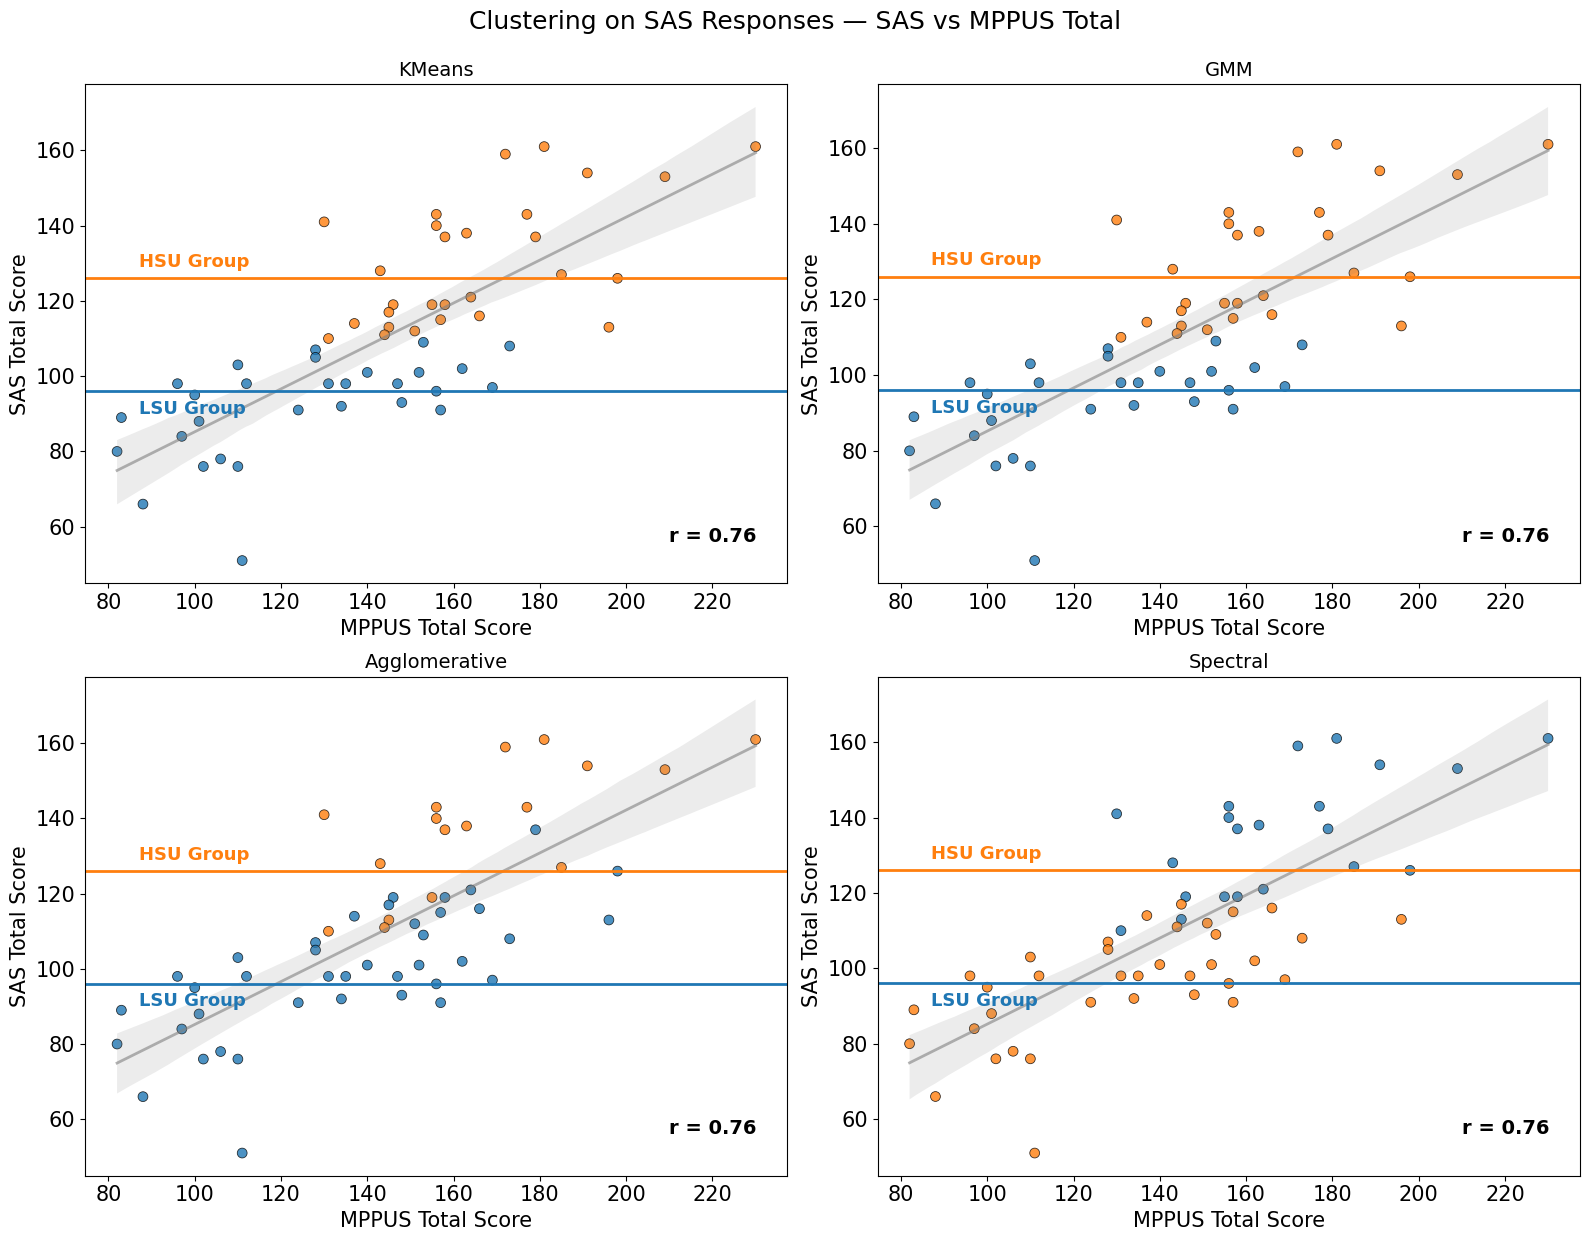

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
cluster_cols = clusterings.keys()

for ax, col in zip(axes.flatten(), cluster_cols):
    plot_cluster_group(mppus_eeg,sas_eeg, col, ax)

plt.tight_layout()
plt.suptitle("Clustering on SAS Responses — SAS vs MPPUS Total", fontsize=18, y=1.03)
plt.show()


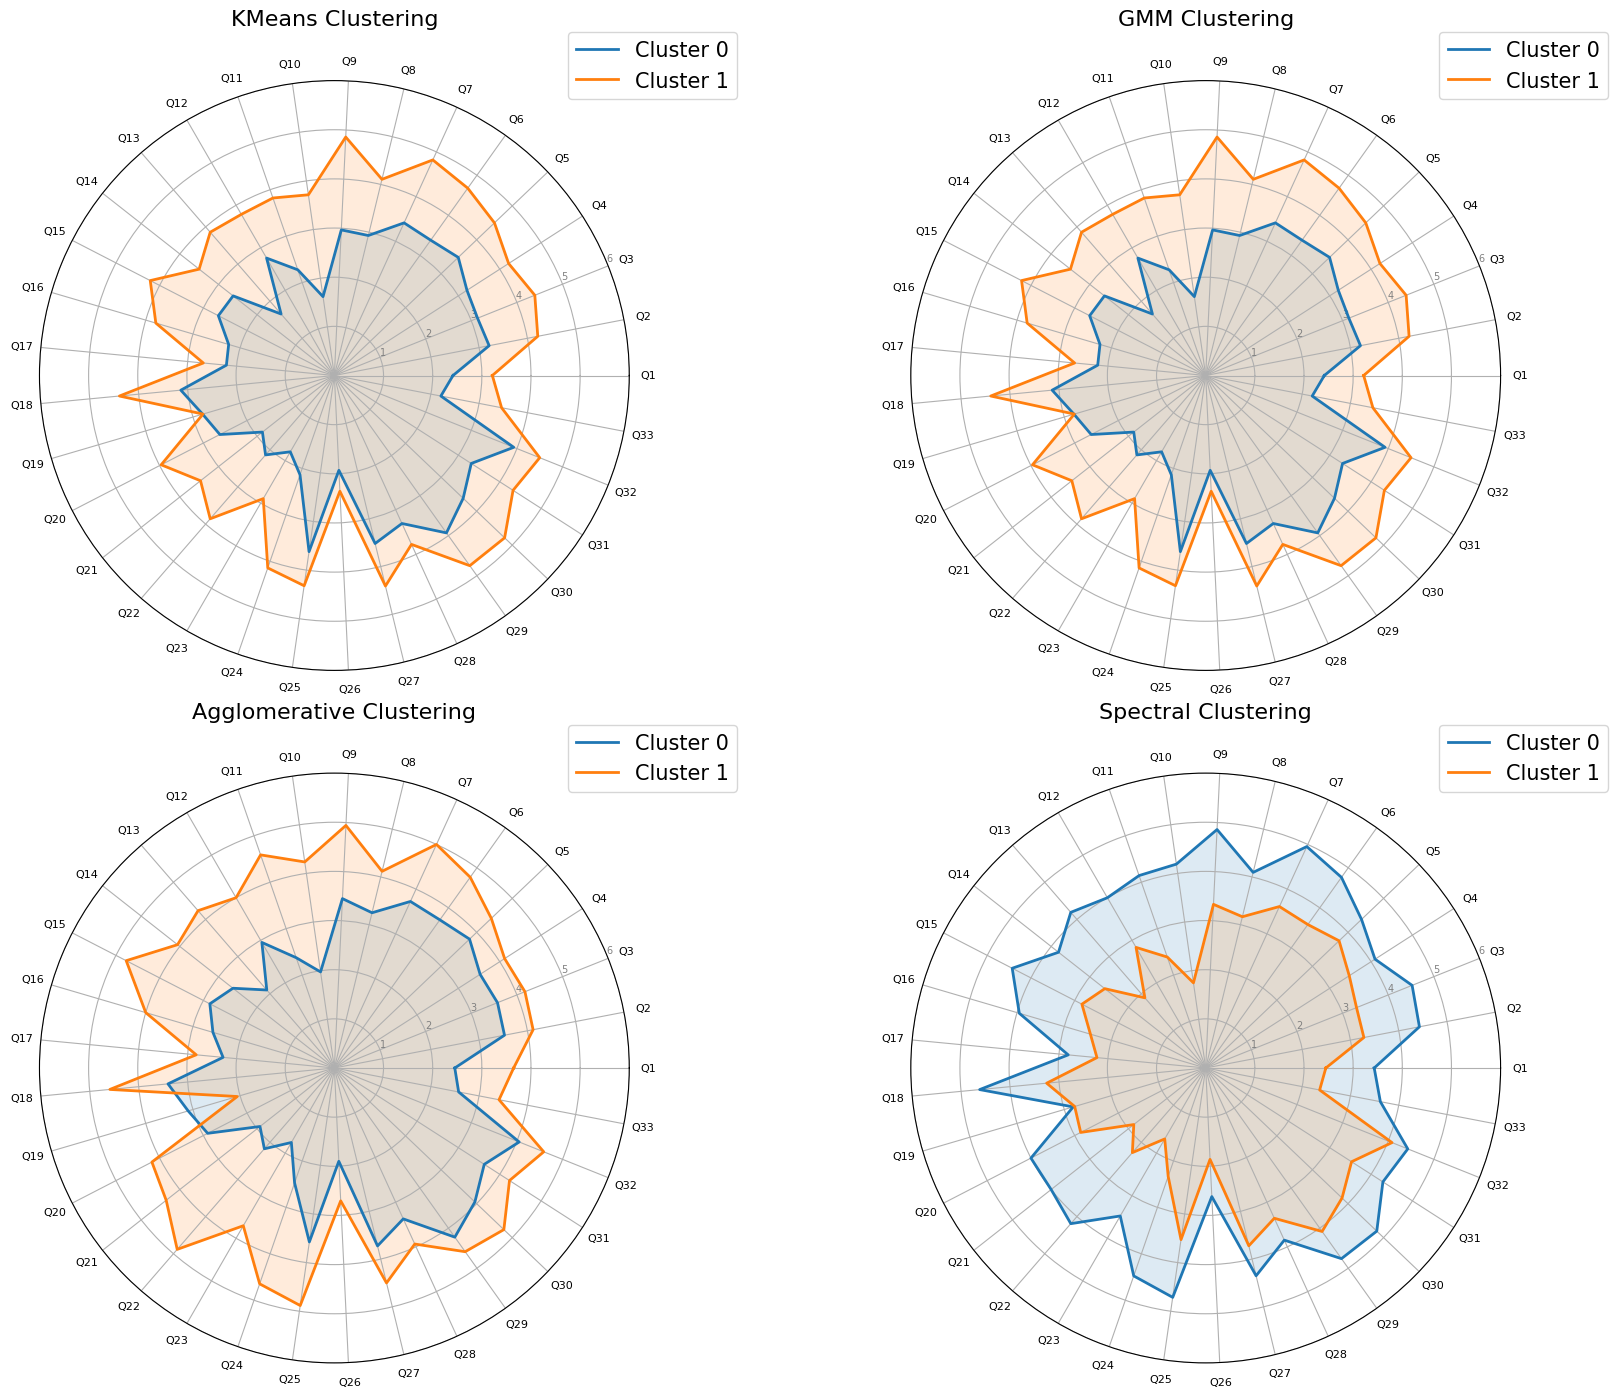

In [22]:
sas_columns = [f'Q{i}' for i in range(1, 34)]
algos = ["KMeans", "GMM", "Agglomerative", "Spectral"]
# Set up radar plot angles
N = len(sas_columns)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # complete the loop

fig, axes = plt.subplots(2, 2, subplot_kw=dict(polar=True), figsize=(18, 14))
axes = axes.flatten()

for idx, algo in enumerate(algos):
    ax = axes[idx]
    cluster_col = f"{algo}_Cluster"
    # Exclude noise points for DBSCAN if present (-1 label)
    clusters = sorted([c for c in sas[cluster_col].unique() if c != -1])
    for cluster in clusters:
        means = sas_eeg[sas_eeg[cluster_col] == cluster][sas_columns].mean().tolist()
        means += means[:1]  # complete the loop
        ax.plot(angles, means, linewidth=2, label=f"Cluster {cluster}")
        ax.fill(angles, means, alpha=0.15)
    ax.set_title(f"{algo} Clustering", size=16, y=1.08)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(sas_columns, size=8)
    ax.set_yticks([1, 2, 3, 4, 5, 6])
    ax.set_yticklabels(['1', '2', '3', '4', '5', '6'], color="grey", size=7)
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()
plt.show()


In [23]:
X_df = sas_eeg[sas_columns]

X_fixed = X_df.fillna(X_df.median()).values

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_fixed)


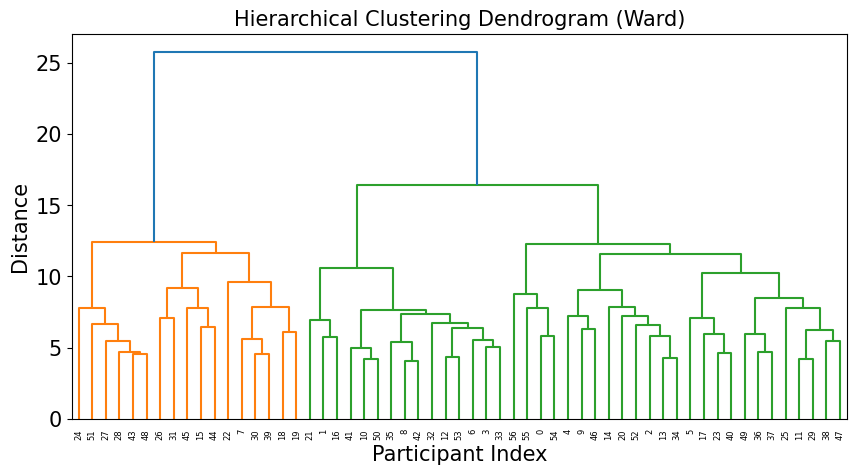

In [24]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("Participant Index")
plt.ylabel("Distance")
plt.show()


In [25]:
# low samrtphone user 
subject_info_D_high = sas_eeg[sas_eeg['GMM_Cluster']==1]
# high smartphone user 
subject_info_D_low = sas_eeg[sas_eeg['GMM_Cluster']==0]
# catogory subject list
 
low_sub_D = list(subject_info_D_low['participant_id'])

high_sub_D = list(subject_info_D_high['participant_id'])
print(len(low_sub_D),len(high_sub_D))

29 28


In [26]:
print(list(sas_eeg['participant_id']))

['sd011', 'sd012', 'sd013', 'sd014', 'sd015', 'sd016', 'sd017', 'sd018', 'sd019', 'sd020', 'sd021', 'sd022', 'sd023', 'sd024', 'sd025', 'sd026', 'sd027', 'sd028', 'sd029', 'sd030', 'sd031', 'sd032', 'sd033', 'sd034', 'sd035', 'sd036', 'sd037', 'sd038', 'sd039', 'sd040', 'sd041', 'sd042', 'sd043', 'sd044', 'sd045', 'sd046', 'sd047', 'sd048', 'sd049', 'sd050', 'sd051', 'sd052', 'sd053', 'sd054', 'sd055', 'sd056', 'sd057', 'sd058', 'sd059', 'sd060', 'sd061', 'sd062', 'sd063', 'sd064', 'sd066', 'sd065', 'sd067']


In [27]:
print(low_sub_D)
print(high_sub_D)

['sd011', 'sd012', 'sd013', 'sd014', 'sd017', 'sd019', 'sd020', 'sd021', 'sd023', 'sd024', 'sd025', 'sd027', 'sd031', 'sd032', 'sd043', 'sd044', 'sd045', 'sd046', 'sd047', 'sd048', 'sd052', 'sd053', 'sd057', 'sd060', 'sd061', 'sd063', 'sd064', 'sd065', 'sd067']
['sd015', 'sd016', 'sd018', 'sd022', 'sd026', 'sd028', 'sd029', 'sd030', 'sd033', 'sd034', 'sd035', 'sd036', 'sd037', 'sd038', 'sd039', 'sd040', 'sd041', 'sd042', 'sd049', 'sd050', 'sd051', 'sd054', 'sd055', 'sd056', 'sd058', 'sd059', 'sd062', 'sd066']


# Statistical test

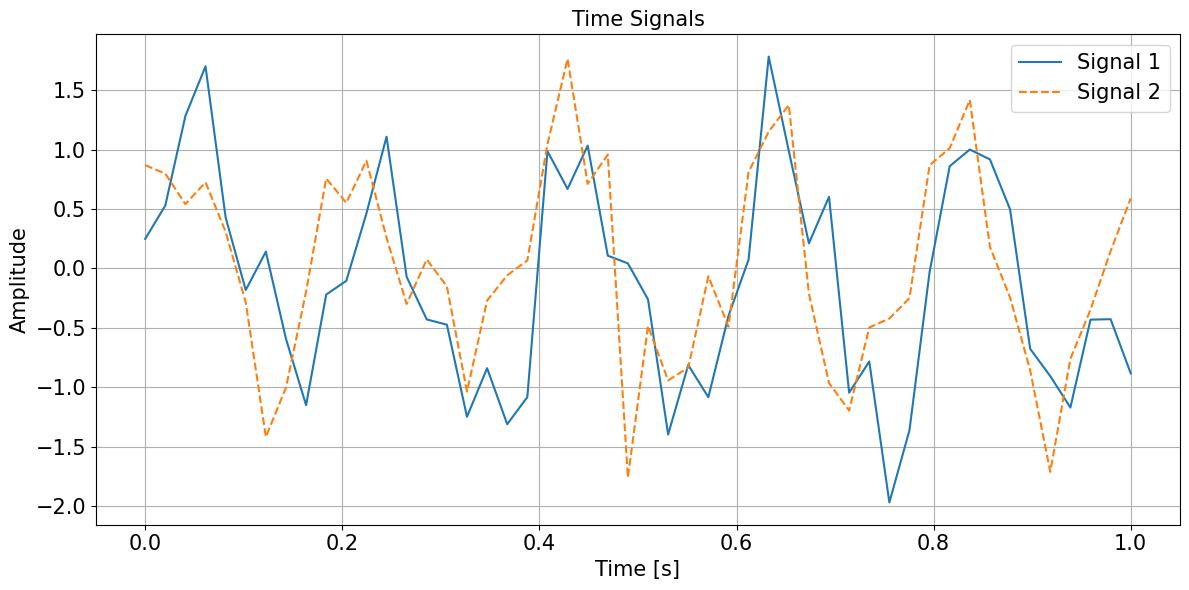

c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 256 is greater than input length  = 50, using nperseg = 50
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


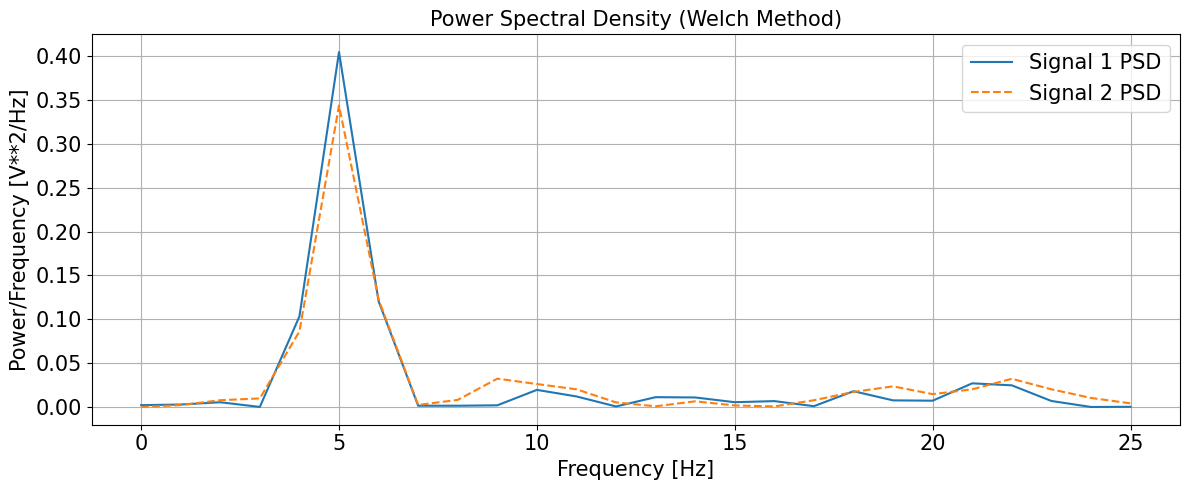

=== Statistical Test Results ===
T-test: stat = -0.7872, p-value = 0.4330
KS-test: stat = 0.1400, p-value = 0.7166
Max Cross-Correlation: 28.5276
Pearson Correlation: 0.5892, p-value = 6.7489e-06


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, ks_2samp, pearsonr
from scipy.signal import welch, correlate

# 1. Generate signals
np.random.seed(42)
t = np.linspace(0, 1, 50)
signal1 = np.sin(2 * np.pi * 5 * t) + 0.5 * np.random.randn(50)
signal2 = np.sin(2 * np.pi * 5 * t + np.pi / 4) + 0.5 * np.random.randn(50)

# 2. Plot signals
plt.figure(figsize=(12, 6))
plt.plot(t, signal1, label='Signal 1')
plt.plot(t, signal2, label='Signal 2', linestyle='--')
plt.title('Time Signals')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Statistical Testing

# a. t-test (mean comparison)
t_stat, t_p = ttest_ind(signal1, signal2)

# b. Kolmogorov–Smirnov test (distribution comparison)
ks_stat, ks_p = ks_2samp(signal1, signal2)

# c. Welch's method (PSD comparison)
freqs1, psd1 = welch(signal1, fs=50)
freqs2, psd2 = welch(signal2, fs=50)

plt.figure(figsize=(12, 5))
plt.plot(freqs1, psd1, label='Signal 1 PSD')
plt.plot(freqs2, psd2, label='Signal 2 PSD', linestyle='--')
plt.title('Power Spectral Density (Welch Method)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power/Frequency [V**2/Hz]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# d. Cross-correlation
correlation = correlate(signal1, signal2, mode='full')
max_corr = np.max(np.abs(correlation))

# e. Pearson correlation
pearson_corr, pearson_p = pearsonr(signal1, signal2)

# 4. Print Results
print("=== Statistical Test Results ===")
print(f"T-test: stat = {t_stat:.4f}, p-value = {t_p:.4f}")
print(f"KS-test: stat = {ks_stat:.4f}, p-value = {ks_p:.4f}")
print(f"Max Cross-Correlation: {max_corr:.4f}")
print(f"Pearson Correlation: {pearson_corr:.4f}, p-value = {pearson_p:.4e}")
